<a href="https://colab.research.google.com/github/hemanth/notebooks/blob/main/smolagents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install -qU smolagents
#!pip install -qU  huggingface_hub

In [5]:
from huggingface_hub import login
import os

HF_TOKEN = os.getenv("HF_TOKEN")

login(HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
from smolagents import CodeAgent, DuckDuckGoSearchTool, HfApiModel

agent = CodeAgent(tools=[DuckDuckGoSearchTool()], 
                  model=HfApiModel(),
                  )

agent.run("What's today's date?")

In [ ]:
llm_model = HfApiModel(model_id='meta-llama/Meta-Llama-3-8B-Instruct')

agent = CodeAgent(
    tools=[DuckDuckGoSearchTool()],
    model=llm_model,
    verbosity_level=2,
    additional_authorized_imports = ['pandas']
)

agent.run("What's today's date?")

In [3]:
import random
import requests
from PIL import Image
from io import BytesIO
from smolagents import Tool
from PIL import Image
import requests
from io import BytesIO
class GetRandomXKCDTool(Tool):
    name = "get_random_xkcd_comic_url"
    description = "Get the URL of a random XKCD comic"
    inputs = {}
    output_type = "string"  # Output is now a URL string

    def __init__(self):
        super().__init__()
        self.base_url = "https://xkcd.com/"
        self.info_url = "https://xkcd.com/info.0.json"

    def forward(self):
        try:
            # Get the latest comic number
            response = requests.get(self.info_url)
            response.raise_for_status()  # Raise an exception for bad status codes
            latest_comic = response.json()
            latest_comic_num = latest_comic["num"]

            # Generate a random comic number
            random_comic_num = random.randint(1, latest_comic_num)

            # Construct the image URL
            image_url = f"{self.base_url}{random_comic_num}/info.0.json"

            response = requests.get(image_url)
            response.raise_for_status()
            comic_data = response.json()
            comic_url = comic_data["img"]
            response = requests.get(comic_url)
            return Image.open(BytesIO(response.content))

        except requests.exceptions.RequestException as e:
            print(f"Error fetching XKCD comic: {e}")
            return None

In [4]:
get_random_xkcd_comic = GetRandomXKCDTool()

In [5]:
get_random_xkcd_comic

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Return me a random XKCD cartoon.                                                                                │
│ You have been provided with these additional arguments, that you can access using the keys as variables in your │
│ python code:                                                                                                    │
│ {'xkcd_comic_url': <PIL.PngImagePlugin.PngImageFile image mode=L size=458x280 at 0x2D66A30DA60>}.               │
│                                                                                                                 │
╰─ HfApiModel - Qwen/Qwen2.5-Coder-32B-Instruct ──────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(xkcd_comic_url)                                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out - Final answer: <PIL.PngImagePlugin.PngImageFile image mode=L size=458x280 at 0x2D66A30DA60>

[Step 1: Duration 3.98 seconds| Input tokens: 2,094 | Output tokens: 62]

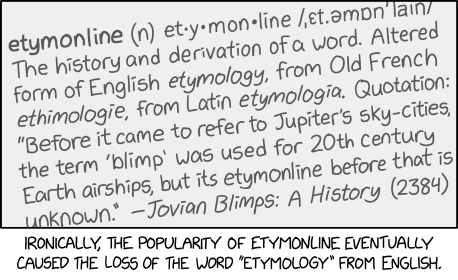

In [6]:
agent = CodeAgent(
    tools = [get_random_xkcd_comic],
    model=HfApiModel(),
)

agent.run(
    "Return me a random XKCD cartoon.", additional_args={"xkcd_comic_url":get_random_xkcd_comic()}
)

In [7]:
#pip install 'smolagents[gradio]'
from smolagents import GradioUI

GradioUI(agent).launch()

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://427ff084498d4ac550.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ ola tudo bem                                                                                                    │
│                                                                                                                 │
╰─ HfApiModel - Qwen/Qwen2.5-Coder-32B-Instruct ──────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("ola tudo bem")                                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out - Final answer: ola tudo bem

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  comic_image = get_random_xkcd_comic_url()                                                                        
  final_answer(comic_image)                                                                                        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out - Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=532x414 at 0x2D66CDE5850>

[Step 5: Duration 5.99 seconds| Input tokens: 12,093 | Output tokens: 347]

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://427ff084498d4ac550.gradio.live
